## Stage 4: Exploratory Data Analysis (EDA)

Visualizing class distribution, sample images per grade,
pixel intensity and augmentation strategy.

In [11]:
from google.colab import files
files.upload()  # upload kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

!kaggle datasets download -d tanlikesmath/diabetic-retinopathy-resized -p /content/DR_dataset --force
!unzip -o -q /content/DR_dataset/diabetic-retinopathy-resized.zip -d /content/DR_dataset
print("✅ Dataset ready")

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/tanlikesmath/diabetic-retinopathy-resized
License(s): unknown
100% 7.25G/7.25G [02:24<00:00, 54.0MB/s]

✅ Dataset ready


In [12]:
import os, cv2, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
CLASS_COLORS = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

print("✅ Imports done")

✅ Imports done


### 4.1 Load Dataset

In [13]:
IMG_DIR    = Path('/content/DR_dataset/resized_train/resized_train')
LABELS_CSV = Path('/content/DR_dataset/trainLabels.csv')

labels_df = pd.read_csv(LABELS_CSV)
records   = []

for _, row in labels_df.iterrows():
    img_path = IMG_DIR / f"{row['image']}.jpeg"
    if img_path.exists():
        records.append({
            'filepath'  : str(img_path),
            'image'     : row['image'],
            'diagnosis' : int(row['level']),
            'class_name': CLASS_NAMES[int(row['level'])],
        })

df = pd.DataFrame(records)
print(f'✅ Loaded: {len(df):,} images')

✅ Loaded: 35,126 images


### 4.2 Class Distribution

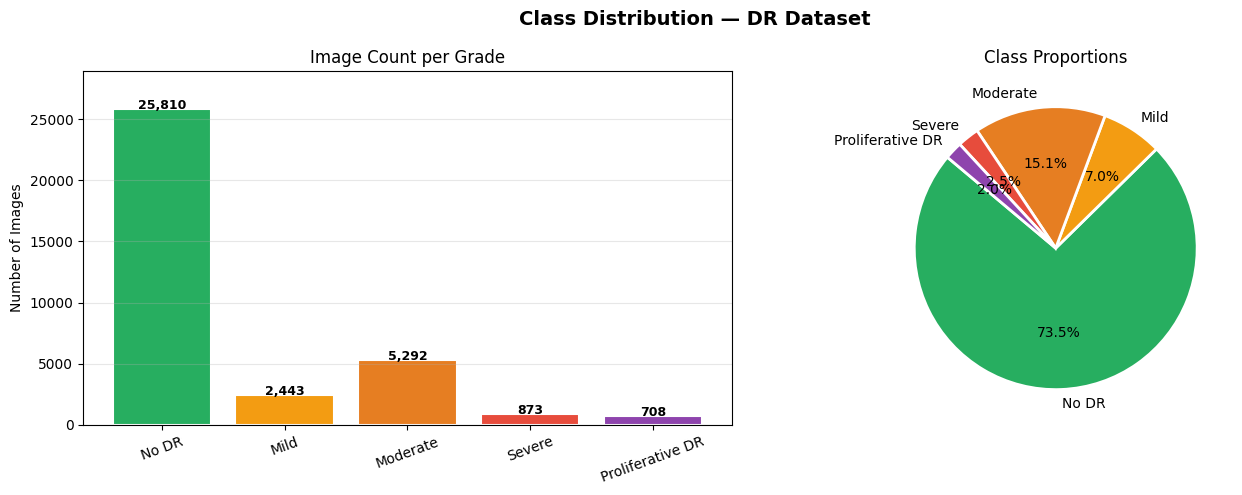

💾 Saved: eda_class_distribution.png


In [14]:
counts = df['diagnosis'].value_counts().sort_index()
total  = len(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — DR Dataset', fontsize=14, fontweight='bold')

bars = axes[0].bar(CLASS_NAMES, counts.values,
                   color=CLASS_COLORS, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{cnt:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Image Count per Grade')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, counts.max() * 1.12)

axes[1].pie(counts.values, labels=CLASS_NAMES, colors=CLASS_COLORS,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_class_distribution.png')

### 4.3 Imbalance Ratio

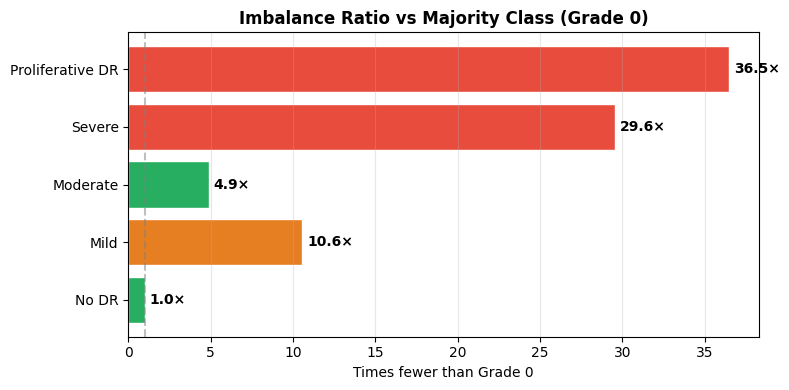

💾 Saved: eda_imbalance_ratio.png


In [15]:
imbalance = counts.max() / counts

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#27ae60' if r < 5 else '#e67e22' if r < 20 else '#e74c3c'
           for r in imbalance.values]

bars = ax.barh(CLASS_NAMES, imbalance.values, color=colors, edgecolor='white')
for bar, val in zip(bars, imbalance.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}×', va='center', fontsize=10, fontweight='bold')

ax.set_title('Imbalance Ratio vs Majority Class (Grade 0)', fontweight='bold')
ax.set_xlabel('Times fewer than Grade 0')
ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_imbalance_ratio.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_imbalance_ratio.png')

### 4.4 Sample Images Per Grade

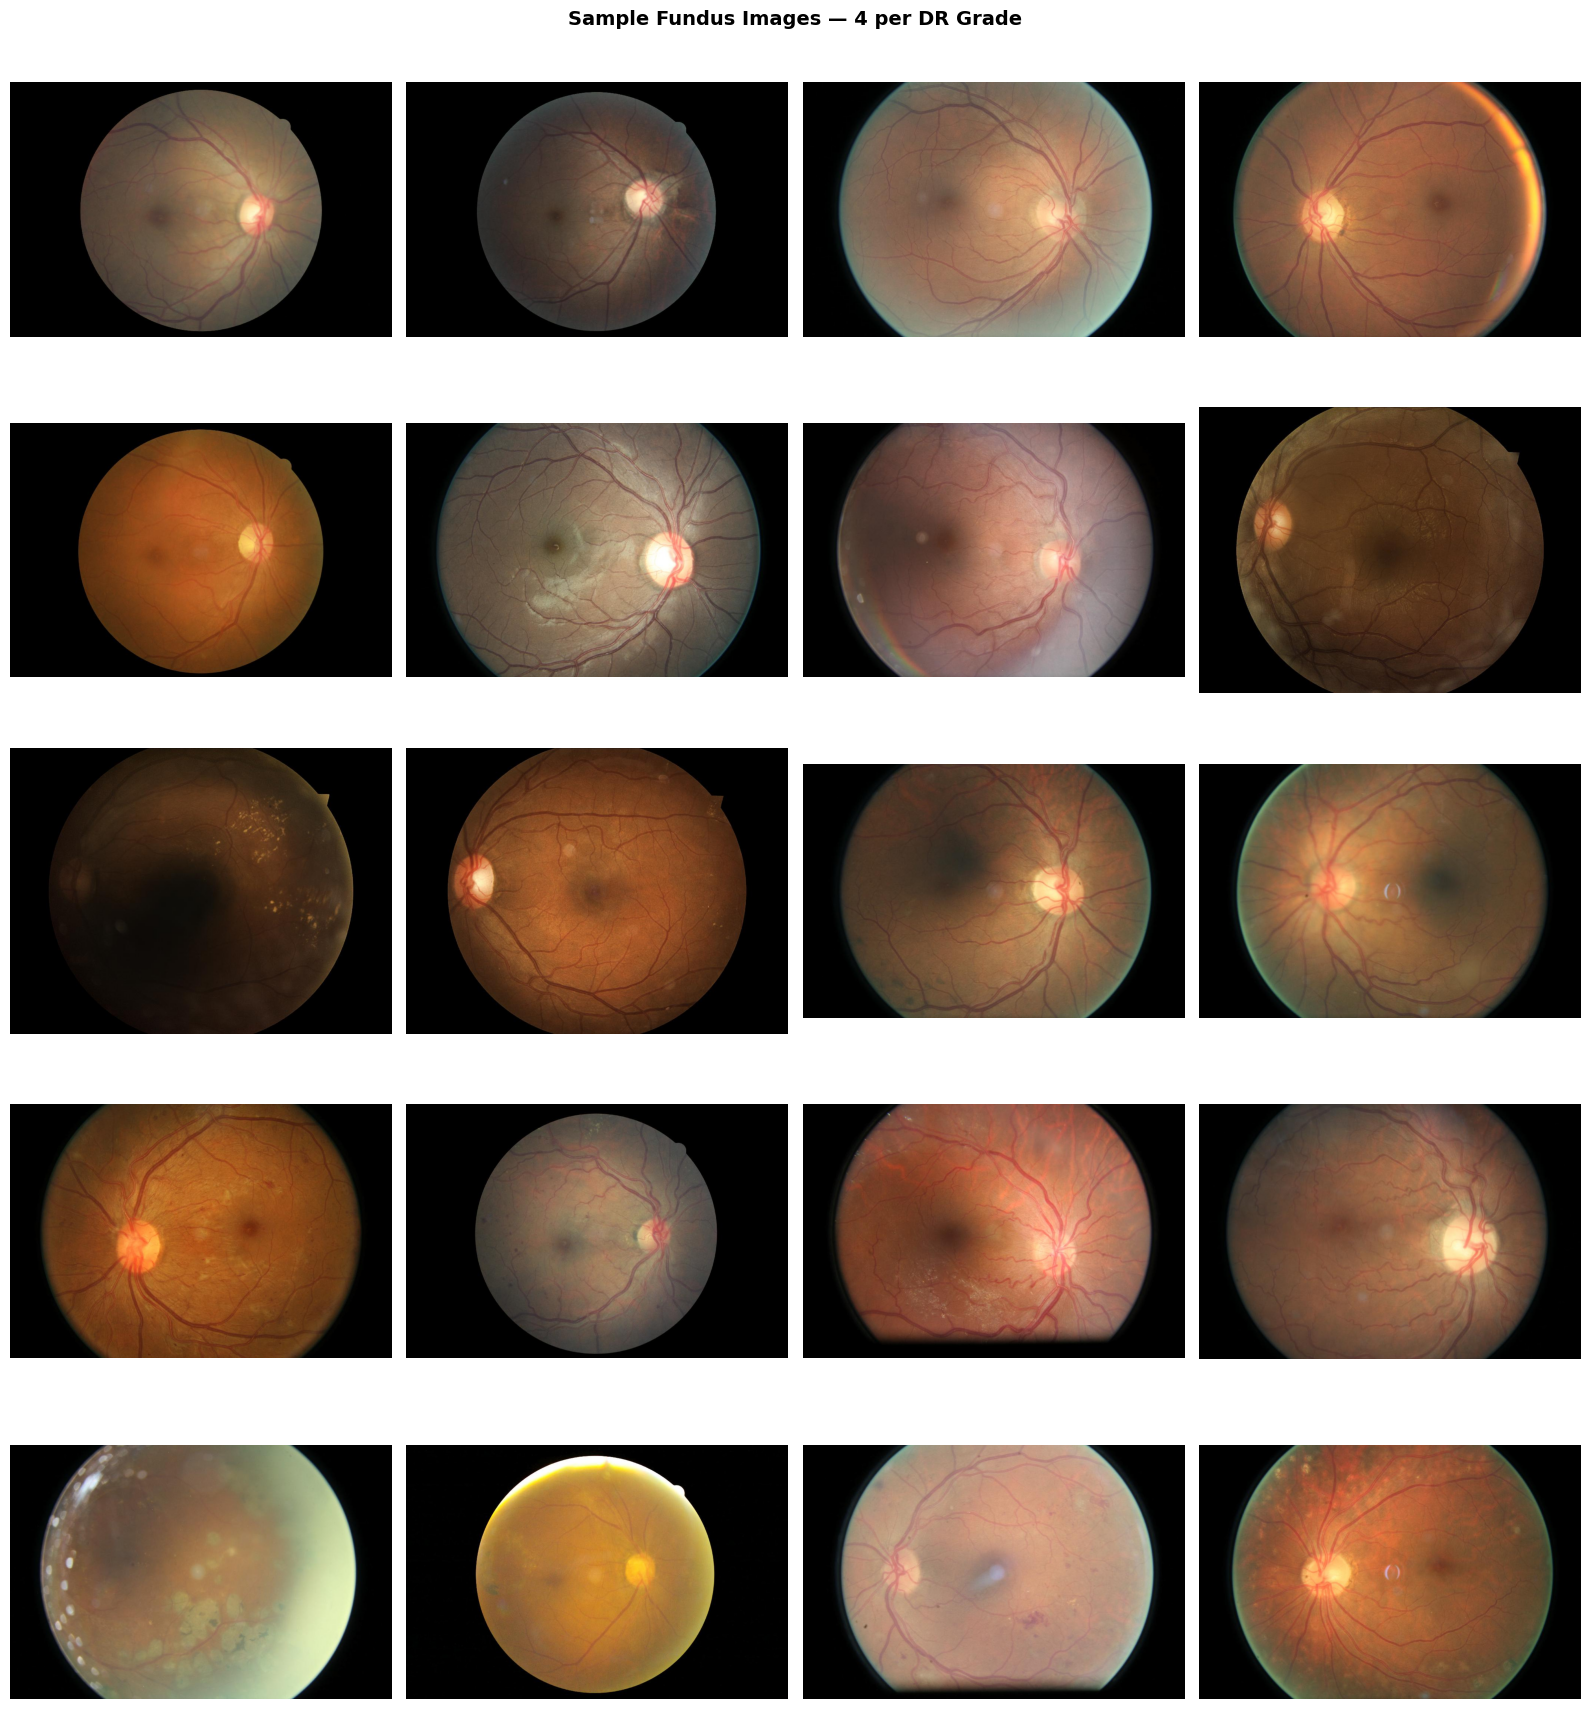

💾 Saved: eda_sample_images.png


In [16]:
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
fig.suptitle('Sample Fundus Images — 4 per DR Grade',
             fontsize=14, fontweight='bold')

for grade in range(5):
    samples = df[df['diagnosis'] == grade].sample(4, random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row['filepath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[grade][j].imshow(img)
        axes[grade][j].axis('off')
        if j == 0:
            axes[grade][j].set_ylabel(
                f'Grade {grade}\n{CLASS_NAMES[grade]}',
                fontsize=10, fontweight='bold',
                rotation=0, labelpad=90, va='center',
                color=CLASS_COLORS[grade]
            )

plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_sample_images.png')

### 4.5 Pixel Intensity Distribution

Pixels:   0%|          | 0/300 [00:00<?, ?it/s]

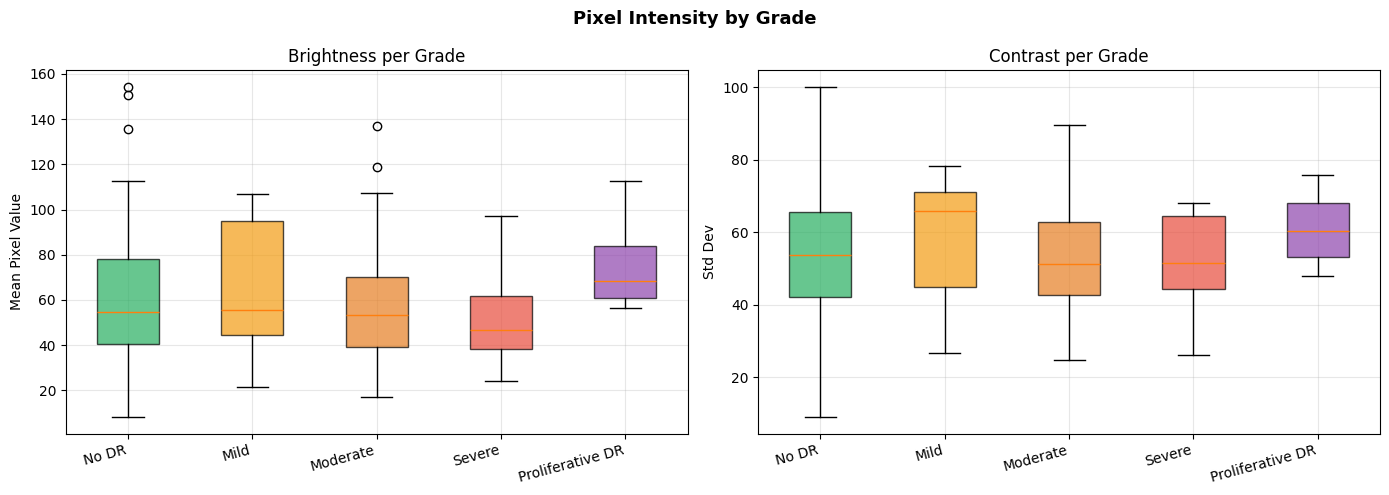

💾 Saved: eda_pixel_intensity.png


In [17]:
pixel_stats = []
for _, row in tqdm(df.sample(300, random_state=SEED).iterrows(),
                   total=300, desc='Pixels'):
    img = cv2.imread(row['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixel_stats.append({
        'grade'     : row['diagnosis'],
        'brightness': img.mean(),
        'contrast'  : img.std(),
    })

ps = pd.DataFrame(pixel_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity by Grade', fontsize=13, fontweight='bold')

data = [ps[ps.grade == g]['brightness'].values for g in range(5)]
bp1  = axes[0].boxplot(data, patch_artist=True)
for patch, color in zip(bp1['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
axes[0].set_ylabel('Mean Pixel Value')
axes[0].set_title('Brightness per Grade')
axes[0].grid(alpha=0.3)

data = [ps[ps.grade == g]['contrast'].values for g in range(5)]
bp2  = axes[1].boxplot(data, patch_artist=True)
for patch, color in zip(bp2['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Contrast per Grade')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_pixel_intensity.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_pixel_intensity.png')

### 4.6 Train vs Validation Split

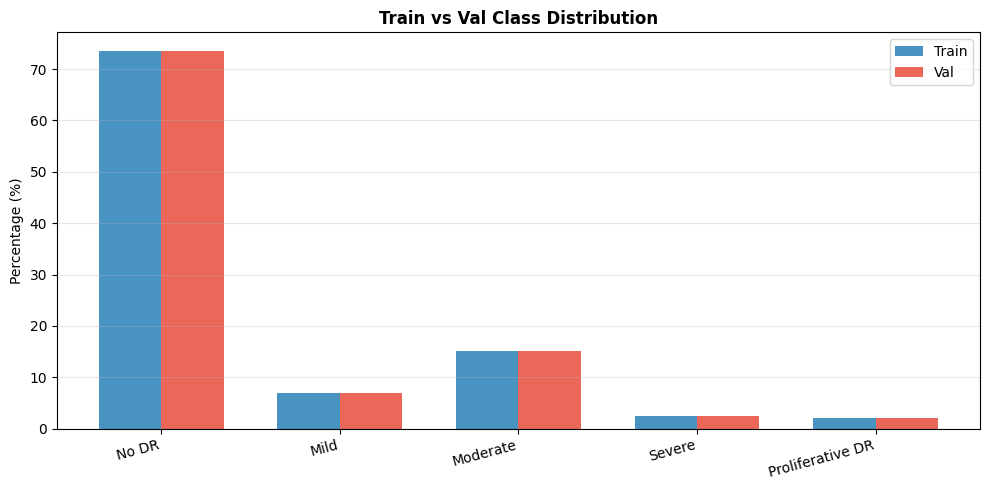

💾 Saved: eda_train_val.png


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
df['fold'] = -1
for i, (_, val_idx) in enumerate(skf.split(df, df['diagnosis'])):
    df.loc[val_idx, 'fold'] = i

train_df = df[df['fold'] != 0].reset_index(drop=True)
val_df   = df[df['fold'] == 0].reset_index(drop=True)

x  = np.arange(5)
w  = 0.35
tr = [train_df['diagnosis'].value_counts().sort_index()[g]/len(train_df)*100 for g in range(5)]
vl = [val_df['diagnosis'].value_counts().sort_index()[g]/len(val_df)*100     for g in range(5)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, tr, w, label='Train', color='#2980b9', alpha=0.85)
ax.bar(x + w/2, vl, w, label='Val',   color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Train vs Val Class Distribution', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_train_val.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_train_val.png')